In [1]:
## Made by:  Walaa Salah Eldin Ali Hassan 
## ID: 221001460
## Date: 28/5/2026


#1- Libraries installation. Why: These libraries are needed for data handling, visualization, machine learning, saving the model, and deployment.
!pip install pandas numpy matplotlib seaborn scikit-learn joblib streamlit

In [31]:
####2- Importing the Libraries. Why: This block imports everything needed for preprocessing, feature selection, modeling, tuning, 
# evaluation, and saving files.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib
import warnings
warnings.filterwarnings("ignore")

In [5]:
###3- Load the Dataset I will use: Stroke data. Why: We load the raw dataset and check its size and first rows to understand the data structure.

df = pd.read_csv("stroke_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [7]:
###4- Data exploration & Understanding. Why: This step checks data types, missing values, duplicated rows, 
# and whether the target classes are balanced or imbalanced.

print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicated rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["stroke"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

Missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_marri

In [9]:
#####5- Data Cleaning. Why: Machine learning models cannot handle missing values directly. We remove useless ID columns, duplicates, 
# fill missing BMI, and clean unclear smoking values.

df_clean = df.copy()

# Drop ID column if it exists because it does not help prediction
if "id" in df_clean.columns:
    df_clean.drop(columns=["id"], inplace=True)

# Remove duplicated rows
df_clean.drop_duplicates(inplace=True)

# Handle missing BMI values using median
if "bmi" in df_clean.columns:
    df_clean["bmi"] = df_clean["bmi"].fillna(df_clean["bmi"].median())

# Replace unknown smoking status with mode
if "smoking_status" in df_clean.columns:
    mode_smoking = df_clean["smoking_status"].mode()[0]
    df_clean["smoking_status"] = df_clean["smoking_status"].replace("Unknown", mode_smoking)

# Remove rows with impossible or missing target values
df_clean = df_clean.dropna(subset=["stroke"])

print("Cleaned dataset shape:", df_clean.shape)
print(df_clean.isnull().sum())

Cleaned dataset shape: (5110, 11)
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [11]:
###6- Feature Engineering. Why: Feature engineering creates new useful variables from existing columns. Age group, BMI category, 
# and glucose risk can help the model learn better health-related patterns.

# Create age group feature
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[0, 18, 35, 50, 65, 100],
    labels=["Child", "Young Adult", "Adult", "Senior", "Elderly"]
)

# Create BMI category feature
df_clean["bmi_category"] = pd.cut(
    df_clean["bmi"],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# Create glucose risk feature
df_clean["glucose_risk"] = pd.cut(
    df_clean["avg_glucose_level"],
    bins=[0, 100, 125, 300],
    labels=["Normal", "Prediabetes", "High"]
)

df_clean.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,bmi_category,glucose_risk
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Elderly,Obese,High
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,Senior,Overweight,High
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Elderly,Obese,Prediabetes
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Adult,Obese,High
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Elderly,Normal,High


In [13]:
##7- Save the Cleaned Dataset

df_clean.to_csv("Cleaned_Stroke_Data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


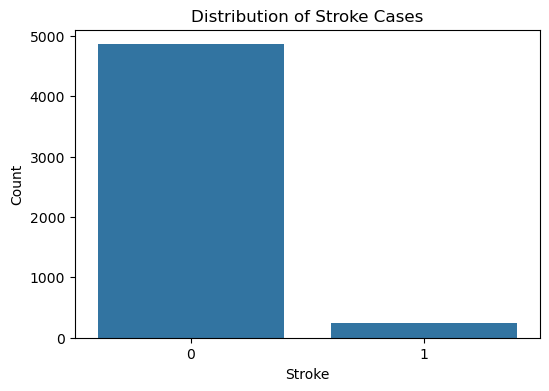

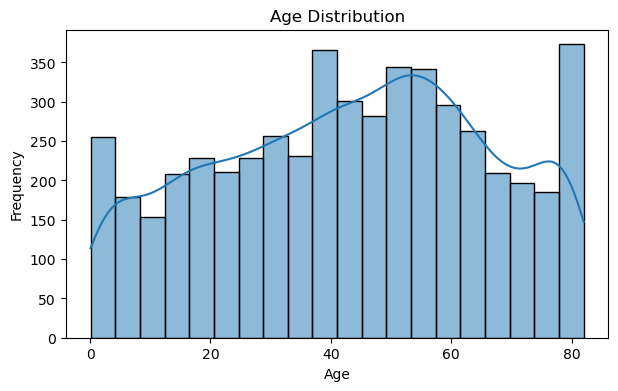

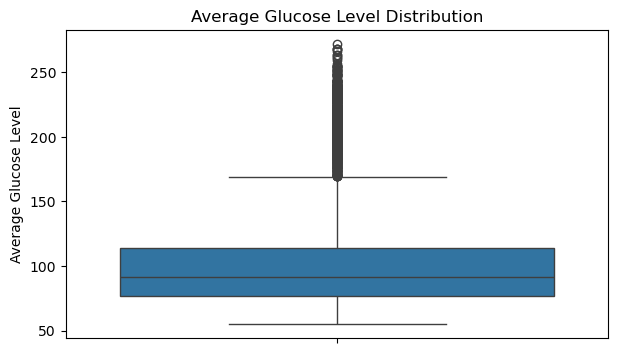

In [15]:
###8- Exploratory Data Analysis ( Univariate Plots ). Why: These plots show the distribution of the target (Stroke), patient ages, and glucose values.
##  This helps us understand the dataset before modeling.

#Stroke
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="stroke")
plt.title("Distribution of Stroke Cases")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

#Age
plt.figure(figsize=(7, 4))
sns.histplot(df_clean["age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#Glucose
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, y="avg_glucose_level")
plt.title("Average Glucose Level Distribution")
plt.ylabel("Average Glucose Level")
plt.show()

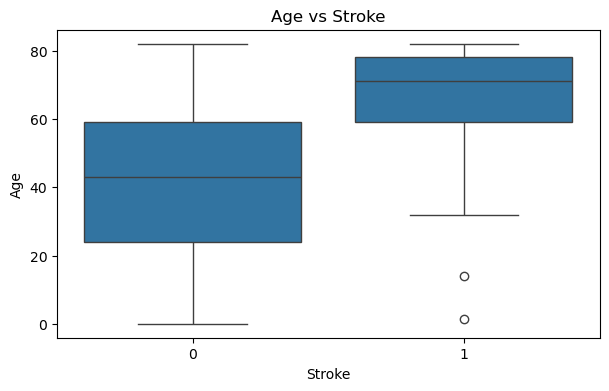

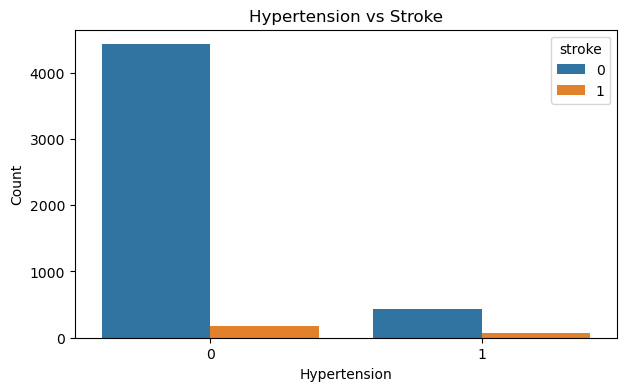

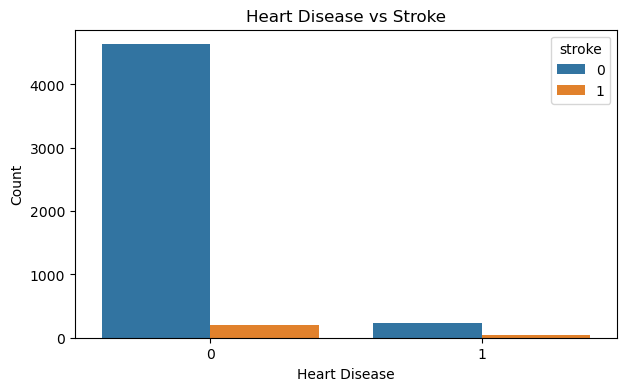

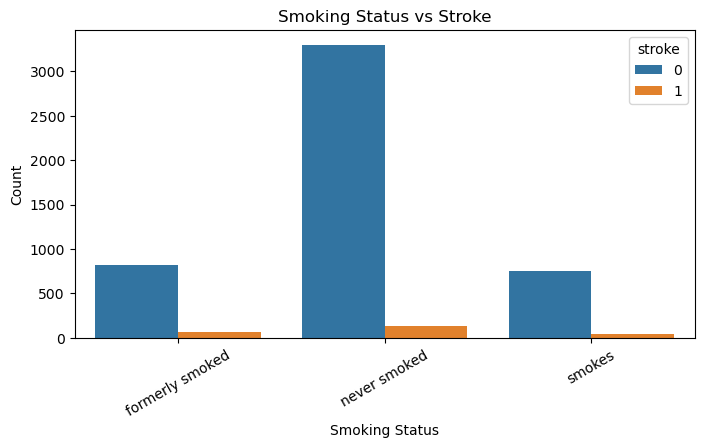

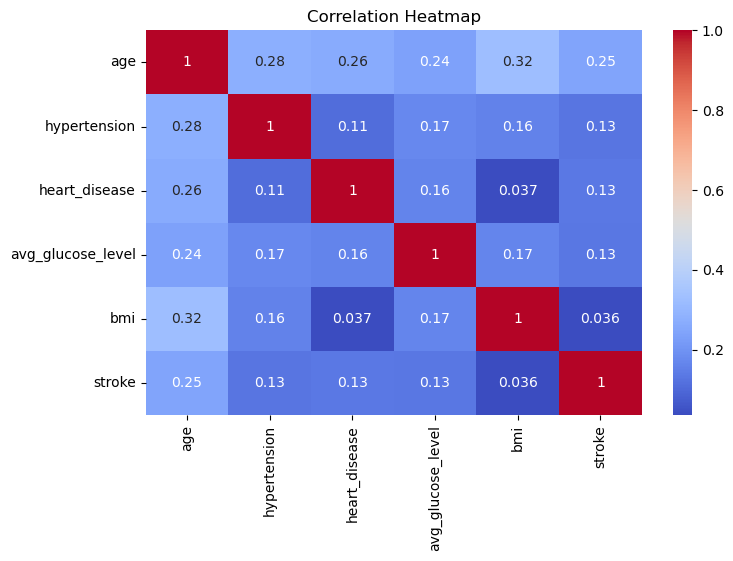

In [17]:
###9- Exploratory Data Analysis ( Bivariate Plots ). Why: We separate the independent variables from the dependent variable 
# because the model learns from X to predict y.

#Stroke vs Age
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x="stroke", y="age")
plt.title("Age vs Stroke")
plt.xlabel("Stroke")
plt.ylabel("Age")
plt.show()

##Stroke vs Hypertension
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="hypertension", hue="stroke")
plt.title("Hypertension vs Stroke")
plt.xlabel("Hypertension")
plt.ylabel("Count")
plt.show()

###Stroke vs Heart Disease
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="heart_disease", hue="stroke")
plt.title("Heart Disease vs Stroke")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

####Stroke vs Smoking Status
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x="smoking_status", hue="stroke")
plt.title("Smoking Status vs Stroke")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

#Correlation Heatmap
plt.figure(figsize=(8, 5))
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [19]:
###10- Separate Features and Target. Why: We separate the independent variables from the dependent variable because the model learns from X to predict y.

X = df_clean.drop(columns=["stroke"])
y = df_clean["stroke"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5110, 13)
Target shape: (5110,)


In [25]:
###11- Train-Test Split. Why: Splitting the data allows us to train on one part and test on unseen data. 
## Stratification keeps the stroke class ratio similar in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("Original target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (4088, 13)
Testing set: (1022, 13)
Original target distribution:
stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

Training target distribution:
stroke
0    0.951321
1    0.048679
Name: proportion, dtype: float64

Testing target distribution:
stroke
0    0.951076
1    0.048924
Name: proportion, dtype: float64


In [27]:
###12- Preprocessing Pipeline. Why: Numeric features need scaling, and categorical features need encoding.
## A pipeline ensures that the same preprocessing is applied during training and deployment.

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categorical features: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'age_group', 'bmi_category', 'glucose_risk']


In [33]:
###13- Comparing Multiple Algorithms. Why: The criteria require trying at least three algorithms. 
## Here I compare 6 models using accuracy, precision, recall, F1-score, and ROC AUC.

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    
    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    
    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("feature_selection", SelectKBest(score_func=f_classif, k=10)),
        ("classifier", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.708415,0.126506,0.84,0.219895,0.838148
1,Decision Tree,0.912916,0.066667,0.06,0.063158,0.508395
2,Random Forest,0.945205,0.250000,0.06,0.096774,0.742202
3,SVM,0.711350,0.127660,0.84,0.221636,0.802531
4,KNN,0.950098,0.333333,0.02,0.037736,0.679496
5,Gradient Boosting,0.949119,0.250000,0.02,0.037037,0.825422


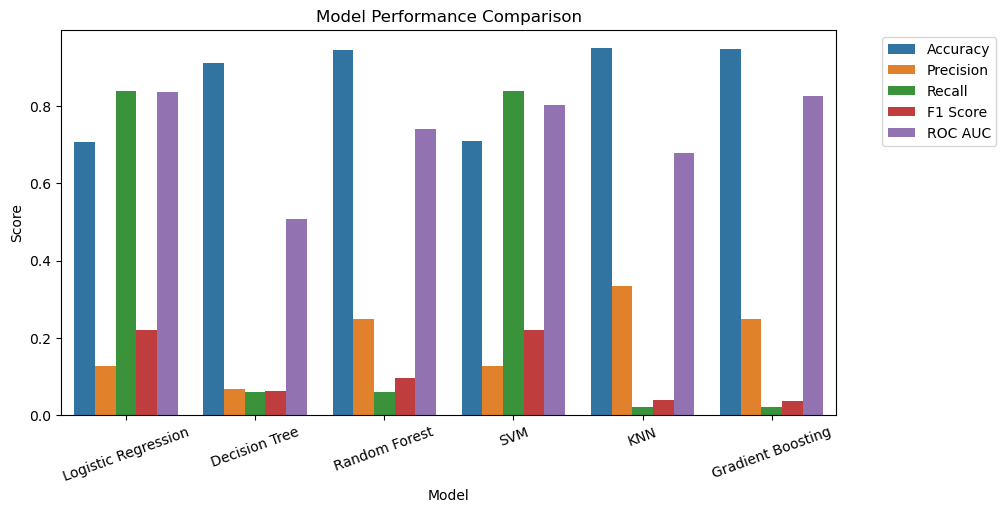

In [35]:
###14- Plot Model Comparison

results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 5))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [37]:
###15- Hyperparameter Tuning with GridSearchCV. Why: Parameter tuning improves model performance by testing different model settings. 
## GridSearchCV chooses the best combination using cross-validation.

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced"))
])

param_grid = {
    "feature_selection__k": [8, 10, 12, "all"],
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("Best cross-validation F1 score:")
print(grid_search.best_score_)

Best parameters:
{'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200, 'feature_selection__k': 'all'}
Best cross-validation F1 score:
0.2255879538421217


In [39]:
###16- Evaluate the Best Model. Why: We evaluate the final model using several metrics. For medical prediction, 
## recall is very important because we want to detect as many risky patients as possible.

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7299412915851272
Precision: 0.13071895424836602
Recall: 0.8
F1 Score: 0.2247191011235955
ROC AUC: 0.8415020576131687

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.13      0.80      0.22        50

    accuracy                           0.73      1022
   macro avg       0.56      0.76      0.53      1022
weighted avg       0.94      0.73      0.81      1022



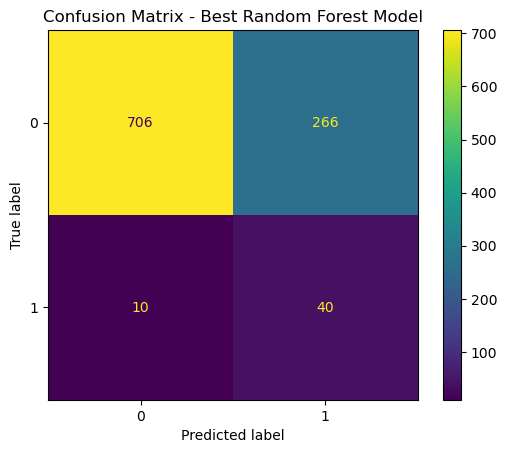

In [41]:
###17- Confusion Matrix. Why: The confusion matrix shows true positives, true negatives, false positives, and false negatives. 
##This helps explain model errors.

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Best Random Forest Model")
plt.show()

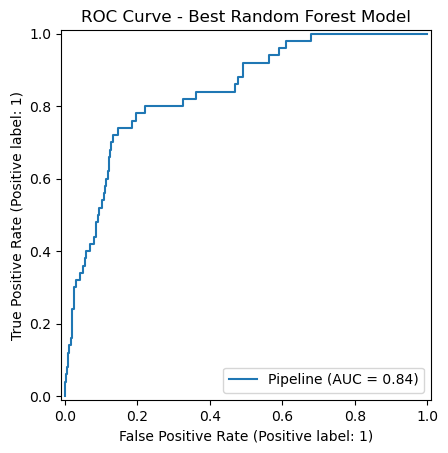

In [43]:
###18- ROC Curve. Why: The ROC curve shows how well the model separates stroke and non-stroke cases across different thresholds.

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve - Best Random Forest Model")
plt.show()

In [45]:
###19- Save Model, Features, and Target. Why: The saved model is needed for deployment. 
###The saved feature and target files are useful for submission and reproducibility.

joblib.dump(best_model, "best_stroke_model.pkl")

X.to_csv("X_features.csv", index=False)
y.to_csv("y_target.csv", index=False)

print("Model saved as best_stroke_model.pkl")
print("X_features.csv and y_target.csv saved successfully.")

Model saved as best_stroke_model.pkl
X_features.csv and y_target.csv saved successfully.


In [47]:
###20- Test Loading the Saved Model. Why: This confirms that the saved model works correctly before using it in Streamlit.

loaded_model = joblib.load("best_stroke_model.pkl")

sample_prediction = loaded_model.predict(X_test.iloc[[0]])
sample_probability = loaded_model.predict_proba(X_test.iloc[[0]])[:, 1]

print("Prediction:", sample_prediction[0])
print("Stroke probability:", sample_probability[0])

Prediction: 0
Stroke probability: 0.48438351862907425


In [49]:
##### Final Saving Codes

# =========================================================
# FINAL EXPORT CODE
# Create GitHub-ready project folder + plots + ZIP download
# =========================================================

import os
import shutil
import zipfile
from pathlib import Path
from IPython.display import FileLink, display

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# ---------------------------------------------------------
# 1. Create project folders
# ---------------------------------------------------------

project_folder = Path("Stroke_Prediction_Project_GitHub_Ready")
plots_folder = project_folder / "plots"

project_folder.mkdir(exist_ok=True)
plots_folder.mkdir(exist_ok=True)

print("Project folder created:", project_folder)
print("Plots folder created:", plots_folder)


# ---------------------------------------------------------
# 2. Save important data files
# ---------------------------------------------------------

# Save cleaned dataset
df_clean.to_csv("Cleaned_Stroke_Data.csv", index=False)

# Save features and target
X.to_csv("X_features.csv", index=False)
y.to_csv("y_target.csv", index=False)

# Save model comparison results
results_df.to_csv("model_comparison_results.csv", index=False)

# Save final model
joblib.dump(best_model, "best_stroke_model.pkl")

print("Main project files saved successfully.")


# ---------------------------------------------------------
# 3. Save final model metrics
# ---------------------------------------------------------

metrics_text = f"""
Final Tuned Model Evaluation

Accuracy: {accuracy_score(y_test, y_pred):.4f}
Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}
Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}
F1 Score: {f1_score(y_test, y_pred, zero_division=0):.4f}
ROC AUC: {roc_auc_score(y_test, y_proba):.4f}

Classification Report:
{classification_report(y_test, y_pred, zero_division=0)}

Model Interpretation:
The final model was evaluated using accuracy, precision, recall, F1-score, ROC AUC,
classification report, confusion matrix, and ROC curve.

Because the stroke dataset is highly imbalanced, accuracy alone is not enough to judge
the model. The model achieved high recall for the stroke class, meaning it detected most
actual stroke cases. This is important in healthcare screening because missing a possible
stroke-risk patient is more serious than incorrectly classifying a low-risk patient as high-risk.

However, the precision for the stroke class was low, meaning that many patients predicted
as high-risk were actually non-stroke cases. Therefore, the model should be interpreted as
a screening support tool, not as a final medical diagnostic system.
"""

with open("final_model_metrics.txt", "w", encoding="utf-8") as f:
    f.write(metrics_text)

print("final_model_metrics.txt saved.")


# ---------------------------------------------------------
# 4. Save plot evaluation text
# ---------------------------------------------------------

plot_evaluation_text = """
Plot Evaluation

1. Target Distribution:
The target variable is highly imbalanced. Most patients belong to the non-stroke class,
while only a small number belong to the stroke class. This means that accuracy alone can
be misleading, and recall, precision, F1-score, ROC AUC, and the confusion matrix should
also be used.

2. Age Distribution:
The dataset contains a wide range of ages. This is useful because age is medically relevant
to stroke prediction.

3. Average Glucose Level Distribution:
Most patients have moderate glucose levels, but there are high glucose outliers. These
values may represent real high-risk patients, so they should not be removed automatically.

4. Age vs Stroke:
Stroke patients are generally older than non-stroke patients. This makes age one of the
strongest predictors in the dataset.

5. Hypertension vs Stroke:
Patients with hypertension show a higher proportional risk of stroke. However, because the
dataset is imbalanced, the plot should be interpreted using proportions, not only counts.

6. Heart Disease vs Stroke:
Heart disease appears to be associated with higher stroke risk. Still, the majority class
dominates the bar heights because most patients did not have a stroke.

7. Smoking Status vs Stroke:
Smoking status does not separate the stroke and non-stroke classes strongly by itself.
It may still contribute to prediction when combined with other features.

8. Correlation Heatmap:
Age has the strongest positive correlation with stroke. Hypertension, heart disease, and
average glucose level also show weaker positive correlations.

9. Model Performance Comparison:
Logistic Regression and SVM achieved the best recall for stroke detection. Some models
such as KNN, Random Forest, and Gradient Boosting achieved high accuracy but very low
recall, meaning they missed many stroke cases.

10. Confusion Matrix:
The confusion matrix shows how many stroke and non-stroke cases were correctly and
incorrectly classified. The model detects many stroke cases but also produces false positives,
which is acceptable for a screening-style healthcare model.

11. ROC Curve:
The ROC curve shows that the final model has good ability to separate stroke-risk patients
from non-stroke patients. A ROC AUC around 0.84 indicates good ranking performance.
"""

with open("plot_evaluation.txt", "w", encoding="utf-8") as f:
    f.write(plot_evaluation_text)

print("plot_evaluation.txt saved.")


# ---------------------------------------------------------
# 5. Save all plots again
# ---------------------------------------------------------

# Plot 1: Target Distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="stroke")
plt.title("Distribution of Stroke Cases")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.savefig(plots_folder / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 2: Age Distribution
plt.figure(figsize=(7, 4))
sns.histplot(df_clean["age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.savefig(plots_folder / "age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 3: Average Glucose Level Distribution
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, y="avg_glucose_level")
plt.title("Average Glucose Level Distribution")
plt.ylabel("Average Glucose Level")
plt.savefig(plots_folder / "glucose_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 4: Age vs Stroke
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x="stroke", y="age")
plt.title("Age vs Stroke")
plt.xlabel("Stroke")
plt.ylabel("Age")
plt.savefig(plots_folder / "age_vs_stroke.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 5: Hypertension vs Stroke
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="hypertension", hue="stroke")
plt.title("Hypertension vs Stroke")
plt.xlabel("Hypertension")
plt.ylabel("Count")
plt.savefig(plots_folder / "hypertension_vs_stroke.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 6: Heart Disease vs Stroke
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="heart_disease", hue="stroke")
plt.title("Heart Disease vs Stroke")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.savefig(plots_folder / "heart_disease_vs_stroke.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 7: Smoking Status vs Stroke
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x="smoking_status", hue="stroke")
plt.title("Smoking Status vs Stroke")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.savefig(plots_folder / "smoking_status_vs_stroke.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 8: Correlation Heatmap
plt.figure(figsize=(8, 5))
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig(plots_folder / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 9: Model Performance Comparison
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(11, 5))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.savefig(plots_folder / "model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 10: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Final Model")
plt.savefig(plots_folder / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot 11: ROC Curve
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve - Final Model")
plt.savefig(plots_folder / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("All plots saved successfully.")


# ---------------------------------------------------------
# 6. Create README.md
# ---------------------------------------------------------

readme_text = """
# Walaa Salah Stroke Prediction Project

## Project Description
This project predicts stroke risk using demographic, medical, and lifestyle information.
The model was trained on a stroke prediction dataset containing variables such as age,
hypertension, heart disease, glucose level, BMI, smoking status, work type, and residence type.

## Project Question
Can machine learning predict whether a patient is at risk of stroke based on clinical and lifestyle features?

## Dataset Overview
The dataset includes:
- Gender
- Age
- Hypertension
- Heart disease
- Ever married
- Work type
- Residence type
- Average glucose level
- BMI
- Smoking status
- Stroke target variable

The target column is:
- stroke: 1 means stroke
- stroke: 0 means no stroke

## Data Cleaning
The dataset was not fully clean. The cleaning phase included:
- Removing the ID column because it does not help prediction
- Handling missing BMI values
- Handling unknown smoking status values
- Checking duplicated rows
- Creating engineered features

## Feature Engineering
New features were created:
- Age group
- BMI category
- Glucose risk category

## Exploratory Data Analysis
The project explored several variables using different visualizations:
- Target distribution plot
- Age distribution plot
- Glucose level boxplot
- Age vs stroke boxplot
- Hypertension vs stroke countplot
- Heart disease vs stroke countplot
- Smoking status vs stroke countplot
- Correlation heatmap

## Models Used
Six machine learning algorithms were compared:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine
5. K-Nearest Neighbors
6. Gradient Boosting

## Evaluation Metrics
The models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC AUC
- Classification report
- Confusion matrix
- ROC curve

## Final Model
The final model was selected based mainly on recall and ROC AUC because the dataset is highly imbalanced.
In healthcare screening, detecting stroke-risk patients is more important than relying only on accuracy.

## Model Interpretation
The model achieved good recall for detecting stroke-risk cases. However, because the dataset is highly
imbalanced, precision was low. This means the model can detect many actual stroke cases, but it may also
classify some non-stroke patients as high-risk.

Therefore, this model is useful as a screening support tool, but it should not replace medical diagnosis.

## Deployment
The final model was deployed using Streamlit.

## How to Run the App
Install the required packages:

```bash
pip install -r requirements.txt

SyntaxError: incomplete input (565563645.py, line 272)